<a href="https://colab.research.google.com/github/emseekim/03_team_project/blob/main/%EB%AF%B8%EC%85%9812_4%ED%8C%80_%EA%B9%80%EB%AF%BC%EC%B2%A0_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 프로젝트 개요 (Project Overview)**

### **1-1. 문제 정의 (Problem Definition)**
* **주제:** 한국어 문서 생성 요약 (Abstractive Summarization) 모델 개발.
* **목표:** 원문(Original Text)의 핵심 내용을 유지하면서 간결한 요약문(Summary)을 생성하는 모델 구현.
* **데이터:** AI Hub 문서요약 텍스트 (신문기사, 사설, 법률 등).

### **1-2. 접근 전략 (Strategy)**
* **데이터 중심(Data-Centric):** 모델링 전, EDA를 통해 입력(Source)과 출력(Target)의 길이 분포를 면밀히 분석하여 최적의 `max_length`를 도출함.
* **평가:** ROUGE Score를 통해 정량적 성능을 검증하고, 실제 생성된 요약문을 원문과 비교하는 정성적 평가 병행.

# **2. 환경 설정 (Environment Setup)**

In [1]:
# 라이브러리 설치 (Install Libraries via uv)
!pip install uv

!uv pip install --system transformers datasets pandas matplotlib seaborn
!uv pip install --system rouge-score  # 평가 지표용
!uv pip install --system kobart-transformers

# 기본 라이브러리 임포트 및 시드 고정 (Reproducibility)
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

# 한글 폰트 설정 (Colab 환경용)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumBarunGothic')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"🔒 Random Seed set to {seed}")

set_seed(42)

# 구글 드라이브 마운트 및 경로 설정
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/My_AI_Project/summary'

# 방어적 코딩: 경로가 실제로 존재하는지 체크
if not os.path.exists(DATA_PATH):
    print(f"⚠️ 경고: {DATA_PATH} 경로를 찾을 수 없습니다.")
    print("구글 드라이브에 폴더를 생성하고 데이터를 업로드 했는지 확인해주세요.")
    # os.makedirs(DATA_PATH, exist_ok=True)
else:
    print(f"✅ 데이터 경로 확인 완료: {DATA_PATH}")
    # 폴더 내 파일 리스트 출력하여 데이터 확인
    print(f"📂 폴더 내 파일 목록: {os.listdir(DATA_PATH)}")

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 사용 장치(Device): {device}")
if str(device) == 'cuda':
    print(f"   GPU Info: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 114.1 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Audited 5 packages in 118ms
Using Python 3.12.12 environment at: /usr
Resolved 9 packages in 761ms
Prepared 1 package in 229ms
Installed 1 package in 0.92ms
 + rouge-score==0.1.2
Using Python 3.12.12 environment at: /usr
Resolved 1 package in 210ms
Prepared 1 package in 92ms
Installed 1 package in 1ms
 + kobart-transformers==0.1.4
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (25.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is i

# **3. 데이터 준비 및 탐색 (EDA)**

### **3-1. JSON 데이터 로드 및 구조 확인 함수 (Defensive Coding)**

In [13]:
import json
import os

# 데이터 경로 재확인 (사용자 환경에 맞게)
DATA_PATH = '/content/drive/MyDrive/My_AI_Project/summary'
target_file = os.path.join(DATA_PATH, 'train_original_news.json')

def inspect_text_structure(file_path):
    print(f"🕵️‍♂️ 데이터 구조 정밀 진단 시작: {os.path.basename(file_path)}")

    if not os.path.exists(file_path):
        print(f"❌ 파일을 찾을 수 없습니다: {file_path}")
        return

    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # documents 리스트 가져오기
    if isinstance(data, dict) and 'documents' in data:
        docs = data['documents']
    else:
        docs = data

    if len(docs) == 0:
        print("⚠️ 문서가 비어있습니다.")
        return

    # 첫 번째 문서의 'text' 필드 심층 분석
    first_doc = docs[0]
    text_data = first_doc.get('text')

    print("\n---------------------------------------------------")
    print(f"📌 [Key Check] 'text' 필드 존재 여부: {'text' in first_doc}")
    print(f"📌 [Type Check] 'text' 필드의 데이터 타입: {type(text_data)}")

    if isinstance(text_data, list):
        print(f"📌 [Length Check] 리스트 길이: {len(text_data)}")
        if len(text_data) > 0:
            first_item = text_data[0]
            print(f"📌 [Inner Type] 리스트 첫 번째 요소의 타입: {type(first_item)}")
            print(f"   - 내용 미리보기: {str(first_item)[:100]}")

            # 만약 리스트 안에 또 리스트가 있다면 (이중 리스트)
            if isinstance(first_item, list):
                 print(f"   👉 [발견] 이중 리스트 구조입니다! (List of Lists)")
                 if len(first_item) > 0:
                     print(f"      - 내부 리스트 첫 요소 타입: {type(first_item[0])}")
                     print(f"      - 내부 내용: {first_item[0]}")
    else:
        print(f"   - 내용 미리보기: {str(text_data)[:100]}")

    print("---------------------------------------------------\n")

# 실행
inspect_text_structure(target_file)

🕵️‍♂️ 데이터 구조 정밀 진단 시작: train_original_news.json

---------------------------------------------------
📌 [Key Check] 'text' 필드 존재 여부: True
📌 [Type Check] 'text' 필드의 데이터 타입: <class 'list'>
📌 [Length Check] 리스트 길이: 11
📌 [Inner Type] 리스트 첫 번째 요소의 타입: <class 'list'>
   - 내용 미리보기: [{'index': 0, 'sentence': 'ha당 조사료 400만원…작물별 차등 지원', 'highlight_indices': ''}]
   👉 [발견] 이중 리스트 구조입니다! (List of Lists)
      - 내부 리스트 첫 요소 타입: <class 'dict'>
      - 내부 내용: {'index': 0, 'sentence': 'ha당 조사료 400만원…작물별 차등 지원', 'highlight_indices': ''}
---------------------------------------------------



### **3-2. 데이터 프레임 변환 (Data Parsing)**

In [5]:
# 실제 AI Hub 데이터 구조에 맞춰 파싱
def convert_to_dataframe(json_data):

    # JSON 리스트에서 필요한 필드(text, summary)만 추출하여 DataFrame으로 변환합니다.
    rows = []

    # 만약 json_data가 dict이고 'documents' 키가 있다면:
    if isinstance(json_data, dict) and 'documents' in json_data:
        items = json_data['documents']
    else:
        items = json_data

    print(f"\n🔄 DataFrame 변환 시작 (총 {len(items)}건)...")

    for item in items:
        # 1. 본문 추출 (text 필드가 리스트인 경우 하나의 문자열로 합침)
        # 구조: 'text': [[sentence1, ...], [sentence2, ...]] 형태일 수 있음
        if 'text' in item:
            # text가 리스트의 리스트 형태인지, 단순 리스트인지 확인 필요
            # 보통 AI Hub는 [ {"index":0, "sentence": "..."}, ... ] 형태일 수도 있음
            # 일단 가장 일반적인 형태(문장 리스트)로 가정하고 예외처리
            try:
                # text 필드 구조에 따라 다를 수 있으므로 일단 단순 병합 시도
                # 만약 item['text']가 리스트라면:
                if isinstance(item['text'], list):
                     # 리스트 내부 요소가 딕셔너리인 경우 (sentence 키 등) 체크 필요하나
                     # AI Hub 문서요약은 보통 [ [문장, 문장], [문장] ] 형태가 많음
                     full_text = ' '.join([str(t) for t in item['text']])
                     # 주의: 실제 구조 보고 수정 필요할 수 있음. 일단 raw string 변환
                else:
                    full_text = str(item['text'])
            except Exception as e:
                full_text = ""
        else:
            full_text = ""

        # 2. 요약문 추출
        summary = item.get('abstractive', [None])[0] if isinstance(item.get('abstractive'), list) else item.get('abstractive')

        # 행 추가
        rows.append({
            'source_text': full_text,
            'target_summary': summary
        })

    df = pd.DataFrame(rows)
    return df

# 데이터 프레임 생성
df = convert_to_dataframe(raw_data)

# 데이터 정제 (결측치 제거)
print(f"   원본 데이터 크기: {len(df)}")
df.dropna(subset=['source_text', 'target_summary'], inplace=True)
print(f"   결측치 제거 후 크기: {len(df)}")

# 결과 확인
print("\n👀 [데이터 프레임 샘플]")
display(df.head(3))


🔄 DataFrame 변환 시작 (총 243983건)...
   원본 데이터 크기: 243983
   결측치 제거 후 크기: 243983

👀 [데이터 프레임 샘플]


,source_text,target_summary
0,"[{'index': 0, 'sentence': 'ha당 조사료 400만원…작물별 차...",전라남도가 쌀 과잉문제를 근본적으로 해결하기 위해 올해부터 벼를 심었던 논에 벼 대...
1,"[{'index': 0, 'sentence': '8억 투입, 고소천사벽화·자산마을에...",여수시는 컬러빌리지 사업에 8억원을 투입하여 ‘색채와 빛’ 도시를 완성하여 고소천사...
2,"[{'index': 0, 'sentence': '전남드래곤즈 해맞이 다짐…선수 영입...",전남드래곤즈 임직원과 선수단이 4일 구봉산 정상에 올라 일출을 보며 2018년 구단...


### **3-3. 이중 리스트 구조 맞춤 파싱 함수 개선 (Refined Parsing)**

In [18]:
def final_convert_to_dataframe(json_data):
    """
    AI Hub 뉴스 데이터의 이중 리스트 구조([[sent, sent], [sent]])를
    완벽하게 파싱하여 DataFrame으로 변환합니다.
    """
    if isinstance(json_data, dict) and 'documents' in json_data:
        items = json_data['documents']
    else:
        items = json_data

    print(f"🔄 최종 데이터 변환 시작 (총 {len(items)}건)...")

    rows = []
    for item in items:
        # --- [Key Logic] 이중 리스트 순회 ---
        full_text_list = []

        # item['text']가 리스트인지 확인
        raw_text = item.get('text')
        if isinstance(raw_text, list):
            for paragraph in raw_text:
                # 1. 문단이 리스트인 경우 (대부분 여기 해당)
                if isinstance(paragraph, list):
                    for sentence_dict in paragraph:
                        if isinstance(sentence_dict, dict):
                            full_text_list.append(sentence_dict.get('sentence', ''))
                # 2. 혹시 문단 없이 바로 딕셔너리인 경우 (예외 처리)
                elif isinstance(paragraph, dict):
                    full_text_list.append(paragraph.get('sentence', ''))

        # 문장들을 공백으로 이어 붙임
        full_text = ' '.join(full_text_list).strip()

        # --- 요약문 파싱 ---
        summary = item.get('abstractive', [None])[0] if isinstance(item.get('abstractive'), list) else item.get('abstractive')

        rows.append({
            'source_text': full_text,
            'target_summary': summary
        })

    df = pd.DataFrame(rows)

    # 결측치 및 빈 텍스트 제거
    original_len = len(df)
    df.dropna(subset=['source_text', 'target_summary'], inplace=True)
    df = df[df['source_text'] != ""]

    print(f"✅ 파싱 완료!")
    print(f"   - 최종 유효 데이터: {len(df)}건 / {original_len}건")

    return df

# 1. 변환 실행
df_news = final_convert_to_dataframe(raw_data)

# 2. 결과 확인 (이제 진짜 깔끔한 문장이 나올 겁니다)
print("\n👀 [최종 데이터 샘플]")
display(df_news.head(3))

🔄 최종 데이터 변환 시작 (총 243983건)...
✅ 파싱 완료!
   - 최종 유효 데이터: 243983건 / 243983건

👀 [최종 데이터 샘플]


,source_text,target_summary
0,ha당 조사료 400만원…작물별 차등 지원 이성훈 sinawi@hanmail.net...,전라남도가 쌀 과잉문제를 근본적으로 해결하기 위해 올해부터 벼를 심었던 논에 벼 대...
1,"8억 투입, 고소천사벽화·자산마을에 색채 입혀 이성훈 sinawi@hanmail.n...",여수시는 컬러빌리지 사업에 8억원을 투입하여 ‘색채와 빛’ 도시를 완성하여 고소천사...
2,전남드래곤즈 해맞이 다짐…선수 영입 활발 이성훈 sinawi@hanmail.net ...,전남드래곤즈 임직원과 선수단이 4일 구봉산 정상에 올라 일출을 보며 2018년 구단...


### **3-4. 길이 분석 및 시각화**

✅ 한글 폰트 설정 완료: NanumBarunGothic
👉 이제 EDA 그래프 코드를 다시 실행하면 한글이 잘 보일 겁니다!

📊 [EDA] 텍스트 길이 분석 시작...

📌 [원문(Source)] 길이 통계 (글자 수 기준)
   - 평균(Mean): 1006.83
   - 최소(Min):  299
   - 최대(Max):  14792
   - 중앙값(Median): 933.0
   - 90% 분위수: 1447.00
   - 95% 분위수: 1603.00
   - 99% 분위수: 1828.00

📌 [요약(Target)] 길이 통계 (글자 수 기준)
   - 평균(Mean): 128.66
   - 최소(Min):  0
   - 최대(Max):  716
   - 중앙값(Median): 125.0
   - 90% 분위수: 177.00
   - 95% 분위수: 192.00
   - 99% 분위수: 225.00


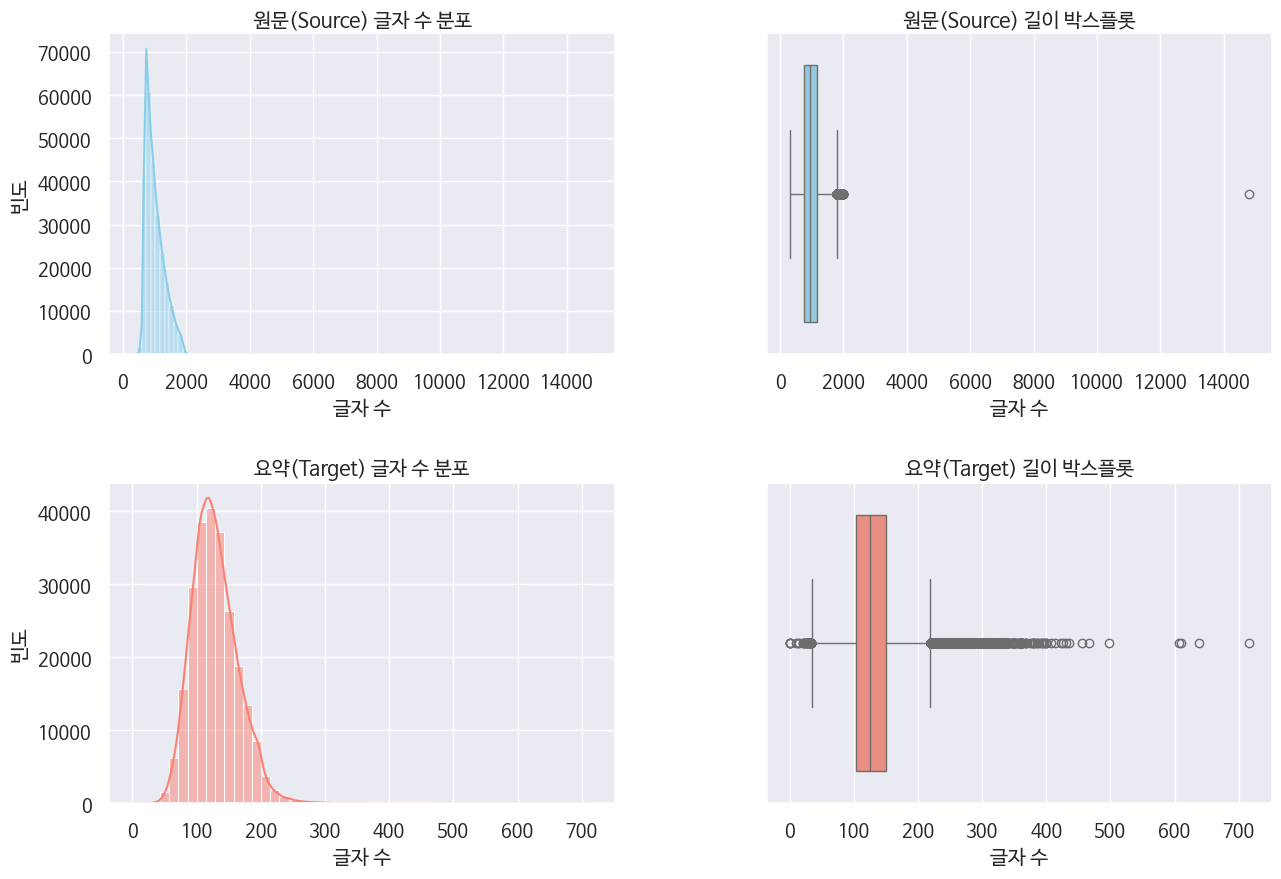


📊 [팩트 체크] 데이터 분포 정밀 분석 시작...

📌 [팩트 1] 가장 긴 데이터 Top 5 (글자 수)
   -> [14792, 1985, 1978, 1976, 1976]
📌 [팩트 2] 상위 1% 경계값: 1828자


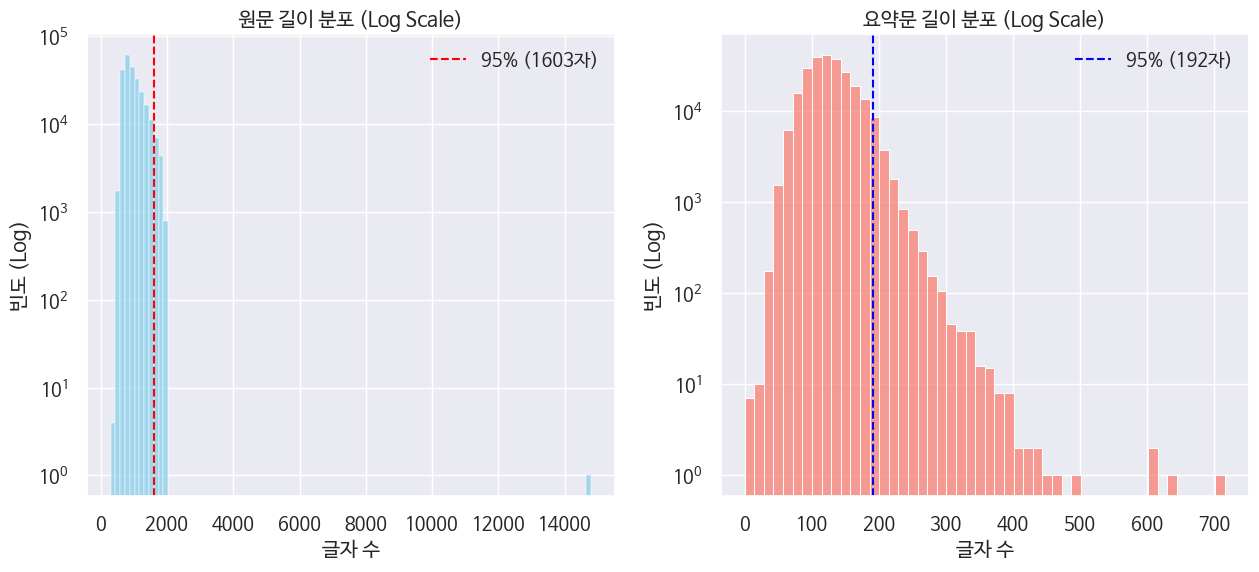

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import numpy as np

# 1. 나눔 폰트 설치 (이미 설치됐어도 안전하게 확인)
!apt-get -qq install fonts-nanum

# 2. 폰트 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path) # 폰트 매니저에 파일 경로 직접 추가
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()

    # 3. Matplotlib에 폰트 적용
    plt.rc('font', family=font_name)
    plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지

    print(f"✅ 한글 폰트 설정 완료: {font_name}")
    print("👉 이제 EDA 그래프 코드를 다시 실행하면 한글이 잘 보일 겁니다!")
else:
    print("❌ 폰트 파일이 아직 설치되지 않았습니다. 잠시 후 다시 실행해보세요.")

print("\n📊 [EDA] 텍스트 길이 분석 시작...")

# 3. 길이 계산 (글자 수 기준)
df_news['source_len'] = df_news['source_text'].apply(len)
df_news['target_len'] = df_news['target_summary'].apply(len)

# 4. 기초 통계 출력 함수
def print_stats(col_name, data):
    print(f"\n📌 [{col_name}] 길이 통계 (글자 수 기준)")
    print(f"   - 평균(Mean): {data.mean():.2f}")
    print(f"   - 최소(Min):  {data.min()}")
    print(f"   - 최대(Max):  {data.max()}")
    print(f"   - 중앙값(Median): {data.median()}")
    print(f"   - 90% 분위수: {data.quantile(0.90):.2f}")
    print(f"   - 95% 분위수: {data.quantile(0.95):.2f}") # ★ 결정의 핵심 기준
    print(f"   - 99% 분위수: {data.quantile(0.99):.2f}")

print_stats("원문(Source)", df_news['source_len'])
print_stats("요약(Target)", df_news['target_len'])

# 5. 시각화 (히스토그램 & 박스플롯) - 요청하신 스타일 적용
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# (1) 원문 길이 분포
sns.histplot(df_news['source_len'], bins=100, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('원문(Source) 글자 수 분포')
axes[0, 0].set_xlabel('글자 수')
axes[0, 0].set_ylabel('빈도')

sns.boxplot(x=df_news['source_len'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('원문(Source) 길이 박스플롯')
axes[0, 1].set_xlabel('글자 수')

# (2) 요약문 길이 분포
sns.histplot(df_news['target_len'], bins=50, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('요약(Target) 글자 수 분포')
axes[1, 0].set_xlabel('글자 수')
axes[1, 0].set_ylabel('빈도')

sns.boxplot(x=df_news['target_len'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('요약(Target) 길이 박스플롯')
axes[1, 1].set_xlabel('글자 수')

plt.show()


# 2. [검증] 데이터 분포 정밀 재확인 (Log Scale)
print("\n📊 [팩트 체크] 데이터 분포 정밀 분석 시작...")

# 1. 길이 재계산 (확실하게 하기 위해)
df_news['source_len'] = df_news['source_text'].apply(len)
df_news['target_len'] = df_news['target_summary'].apply(len)

# 2. 상위 1% 데이터 직접 출력 (눈으로 확인)
# 그래프가 안 보여도 텍스트는 거짓말을 안 합니다.
top_1_percent_idx = int(len(df_news) * 0.01)
sorted_lens = sorted(df_news['source_len'], reverse=True)
print(f"\n📌 [팩트 1] 가장 긴 데이터 Top 5 (글자 수)")
print(f"   -> {sorted_lens[:5]}")
print(f"📌 [팩트 2] 상위 1% 경계값: {sorted_lens[top_1_percent_idx]}자")

# 3. 로그 스케일 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (1) 원문 분포 (Y축 로그 변환)
# bins=100으로 더 잘게 쪼개서 봅니다.
sns.histplot(df_news['source_len'], bins=100, color='skyblue', ax=axes[0])
axes[0].set_yscale('log')  # ★ 핵심: 로그 스케일 적용
axes[0].set_title('원문 길이 분포 (Log Scale)')
axes[0].set_ylabel('빈도 (Log)')
axes[0].set_xlabel('글자 수')

# 95% 지점에 빨간 선 긋기
p95 = df_news['source_len'].quantile(0.95)
axes[0].axvline(p95, color='red', linestyle='--', label=f'95% ({int(p95)}자)')
axes[0].legend()

# (2) 요약문 분포 (Y축 로그 변환)
sns.histplot(df_news['target_len'], bins=50, color='salmon', ax=axes[1])
axes[1].set_yscale('log') # ★ 핵심: 로그 스케일 적용
axes[1].set_title('요약문 길이 분포 (Log Scale)')
axes[1].set_ylabel('빈도 (Log)')
axes[1].set_xlabel('글자 수')

p95_target = df_news['target_len'].quantile(0.95)
axes[1].axvline(p95_target, color='blue', linestyle='--', label=f'95% ({int(p95_target)}자)')
axes[1].legend()

plt.show()

### **[팩트 검증] 그래프 해석 배제, 수치 기반 증명**

In [26]:
import numpy as np

# 1. 꼬리 데이터(Outlier) 실체 확인
# 기준: 2,000자(약 800~1000토큰) 이상인 데이터 개수
long_data_count = len(df_news[df_news['source_len'] > 2000])
total_count = len(df_news)
long_ratio = (long_data_count / total_count) * 100

print(f"📊 [팩트 1] 2,000자가 넘는 데이터의 실체")
print(f"   - 전체 데이터: {total_count}개")
print(f"   - 2,000자 초과 데이터: {long_data_count}개")
print(f"   - 비율: {long_ratio:.2f}%")

# 2. 패딩(Padding) 낭비율 계산 (효율성 검증)
# 시나리오 A: 가장 긴 놈(Max)에 맞춰서 길이를 잡았을 때
max_len_scenario_A = df_news['source_len'].max() # 약 14,000
# 시나리오 B: 95% 컷(1,600)에 맞춰서 길이를 잡았을 때
max_len_scenario_B = 1600

# 모든 데이터에 대해 '낭비되는 공간' 계산
# (설정된 길이 - 실제 자기 길이)가 곧 0으로 채워질 패딩 공간임
waste_A = (max_len_scenario_A - df_news['source_len']).clip(lower=0).sum()
total_capacity_A = max_len_scenario_A * total_count

waste_B = (max_len_scenario_B - df_news['source_len']).clip(lower=0).sum()
total_capacity_B = max_len_scenario_B * total_count

print(f"\n🗑️ [팩트 2] 메모리 낭비율(Padding Ratio) 비교")
print(f"   (A) 자르지 않고 최대 길이({max_len_scenario_A}자)로 설정 시:")
print(f"       -> 전체 공간 중 {(waste_A / total_capacity_A * 100):.2f}%가 빈칸(0)입니다.")
print(f"   (B) 95% 기준({max_len_scenario_B}자)으로 설정 시:")
print(f"       -> 전체 공간 중 {(waste_B / total_capacity_B * 100):.2f}%가 빈칸(0)입니다.")

print("\n---------------------------------------------")
if (waste_A / total_capacity_A) > 0.8:
    print("📢 결론: 시나리오 A는 80% 이상이 빈 공간입니다. 비효율적입니다.")
else:
    print("📢 결론: 시나리오 A도 해볼 만합니다. 굳이 자를 필요 없습니다.")

📊 [팩트 1] 2,000자가 넘는 데이터의 실체
   - 전체 데이터: 243983개
   - 2,000자 초과 데이터: 1개
   - 비율: 0.00%

🗑️ [팩트 2] 메모리 낭비율(Padding Ratio) 비교
   (A) 자르지 않고 최대 길이(14792자)로 설정 시:
       -> 전체 공간 중 93.19%가 빈칸(0)입니다.
   (B) 95% 기준(1600자)으로 설정 시:
       -> 전체 공간 중 37.51%가 빈칸(0)입니다.

---------------------------------------------
📢 결론: 시나리오 A는 80% 이상이 빈 공간입니다. 비효율적입니다.


# **4. 데이터 전처리 (Data Preprocessing)**

## 의도
수집된 원본 데이터(Raw Data)에는 불필요한 공백, 줄바꿈 기호, 혹은 학습을 방해하는 특수문자가 포함되어 있을 수 있습니다.
모델이 텍스트의 의미를 더 잘 파악할 수 있도록 텍스트를 정제(Cleaning)하고, 학습용(Train)과 검증용(Validation) 데이터로 분리합니다.

## 주요 작업
1. **텍스트 정제:** 정규표현식(Regex)을 사용하여 불필요한 줄바꿈(`\n`)이나 다중 공백을 제거합니다.
2. **데이터 분할:** 전체 데이터를 학습용(90%)과 검증용(10%)으로 나누어 과적합(Overfitting)을 감시합니다.

### **4-1. 데이터 전처리 함수 정의**

In [7]:
import re

def preprocess_text(text):
    """
    텍스트 정제 함수:
    1. 줄바꿈 제거
    2. 다중 공백 축소
    3. 양쪽 공백 제거
    """
    if not isinstance(text, str):
        return ""

    # 1. 줄바꿈 문자를 공백으로 변경
    text = text.replace('\n', ' ')
    # 2. 연속된 공백을 하나의 공백으로 축소
    text = re.sub(r'\s+', ' ', text)
    # 3. 양쪽 공백 제거
    return text.strip()

print("✅ 전처리 함수(preprocess_text)가 메모리에 등록되었습니다.")

✅ 전처리 함수(preprocess_text)가 메모리에 등록되었습니다.


In [63]:
# import pandas as pd
# import os
# import re
# from sklearn.model_selection import train_test_split

# print("\n" + "="*60)
# print("📂 Step 5. 데이터 로드 및 전처리 프로세스 가동")
# print("="*60)

# # 1. 환경 설정
# DATA_PATH = '/content/drive/MyDrive/My_AI_Project/summary/processed_data.csv'
# SAMPLE_SIZE = 5000  # 빠른 실험용

# # [Logic 1] 텍스트 정제 함수 정의 (사용자 원본 코드 유지)
# def preprocess_text(text):
#     if not isinstance(text, str):
#         return ""
#     # 1. 줄바꿈 문자를 공백으로 변경
#     text = text.replace('\n', ' ')
#     # 2. 연속된 공백을 하나의 공백으로 축소
#     text = re.sub(r'\s+', ' ', text)
#     # 3. 양쪽 공백 제거
#     return text.strip()

# # [Logic 2] 데이터 로드 및 전처리 적용 (Cleaning & Deduplication)
# if os.path.exists(DATA_PATH):
#     print(f"📥 데이터 파일 로드 중... ({DATA_PATH})")
#     df_news = pd.read_csv(DATA_PATH)

#     # [방어 코드] 결측치 제거
#     df_news.dropna(subset=['source_text', 'target_summary'], inplace=True)

#     print("🧹 텍스트 정제(Cleaning) 적용 중... (함수 적용)")
#     # ★ 사용자님 코드대로 실제 적용 (.apply)
#     df_news['source_text'] = df_news['source_text'].apply(preprocess_text)
#     df_news['target_summary'] = df_news['target_summary'].apply(preprocess_text)

#     print(f"   - 정제 샘플: {df_news.iloc[0]['source_text'][:50]}...")

#     # [방어 코드] 중복 제거 (아까 합의한 내용 추가)
#     initial_len = len(df_news)
#     df_news.drop_duplicates(subset=['source_text'], inplace=True)
#     print(f"   - 중복 제거 완료: {initial_len - len(df_news)}건 삭제됨 (현재 {len(df_news)}건)")

#     # [Logic 3] 데이터 분할 (Split)
#     print(f"\n✂️ 데이터 분할 진행 (Target Size: {SAMPLE_SIZE})...")

#     if len(df_news) > SAMPLE_SIZE:
#         df_sample = df_news.sample(n=SAMPLE_SIZE, random_state=42)
#         print(f"   ⚡ {SAMPLE_SIZE}개 데이터만 샘플링하여 진행합니다.")
#     else:
#         df_sample = df_news

#     train_df, val_df = train_test_split(df_sample, test_size=0.1, random_state=42)

#     print(f"\n✅ [최종 완료] 데이터 준비 끝!")
#     print(f"   - 학습용(train_df): {len(train_df)}건")
#     print(f"   - 검증용(val_df): {len(val_df)}건")

# else:
#     print(f"❌ 오류: 데이터 파일이 없습니다. ({DATA_PATH})")


📂 Step 5. 데이터 로드 및 전처리 프로세스 가동
📥 데이터 파일 로드 중... (/content/drive/MyDrive/My_AI_Project/summary/processed_data.csv)
🧹 텍스트 정제(Cleaning) 적용 중... (함수 적용)
   - 정제 샘플: ha당 조사료 400만원…작물별 차등 지원 이성훈 sinawi@hanmail.net 전라남...
   - 중복 제거 완료: 326건 삭제됨 (현재 243653건)

✂️ 데이터 분할 진행 (Target Size: 5000)...
   ⚡ 5000개 데이터만 샘플링하여 진행합니다.

✅ [최종 완료] 데이터 준비 끝!
   - 학습용(train_df): 4500건
   - 검증용(val_df): 500건


In [5]:
# import re
# from sklearn.model_selection import train_test_split

# # 1) 텍스트 정제 함수 정의
# def preprocess_text(text):
#     if not isinstance(text, str):
#         return ""
#     # 1. 줄바꿈 문자를 공백으로 변경
#     text = text.replace('\n', ' ')
#     # 2. 연속된 공백을 하나의 공백으로 축소
#     text = re.sub(r'\s+', ' ', text)
#     # 3. 양쪽 공백 제거
#     return text.strip()

# print("🧹 텍스트 정제(Cleaning) 시작...")
# # 원문과 요약문에 모두 적용
# df_news['source_text'] = df_news['source_text'].apply(preprocess_text)
# df_news['target_summary'] = df_news['target_summary'].apply(preprocess_text)

# print(f"   - 정제 완료! (샘플): {df_news.iloc[0]['source_text'][:50]}...")

# # 2) 데이터 분할 (Train / Validation)
# # 빠른 실험을 위해 5,000개 샘플링 (실전에서는 전체 사용)
# SAMPLE_SIZE = 5000
# print(f"\n✂️ 데이터 분할 진행 (Total: {SAMPLE_SIZE})...")

# if len(df_news) > SAMPLE_SIZE:
#     df_sample = df_news.sample(n=SAMPLE_SIZE, random_state=42)
# else:
#     df_sample = df_news

# train_df, val_df = train_test_split(df_sample, test_size=0.1, random_state=42)

# print(f"✅ 데이터 전처리 및 분할 완료")
# print(f"   - 학습용: {len(train_df)}건 / 검증용: {len(val_df)}건")

🧹 텍스트 정제(Cleaning) 시작...
   - 정제 완료! (샘플): ha당 조사료 400만원…작물별 차등 지원 이성훈 sinawi@hanmail.net 전라남...

✂️ 데이터 분할 진행 (Total: 5000)...
✅ 데이터 전처리 및 분할 완료
   - 학습용: 4500건 / 검증용: 500건


### **4-2. 데이터 로드 및 전처리 적용 (Execution)**

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

print("\n" + "="*60)
print("📂 Step 5. 데이터 로드 및 파이프라인 가동")
print("="*60)

# 1. 환경 설정
DATA_PATH = '/content/drive/MyDrive/My_AI_Project/summary/processed_data.csv'
SAMPLE_SIZE = 5000

if os.path.exists(DATA_PATH):
    print(f"📥 데이터 로드 중... ({DATA_PATH})")
    df_news = pd.read_csv(DATA_PATH)

    # [무결성] 결측치 제거
    df_news.dropna(subset=['source_text', 'target_summary'], inplace=True)

    print("🧹 텍스트 정제 함수 적용 중... (Step 4 함수 사용)")
    # ★ 위(Step 4)에서 만든 함수를 여기서 가져다 씁니다.
    df_news['source_text'] = df_news['source_text'].apply(preprocess_text)
    df_news['target_summary'] = df_news['target_summary'].apply(preprocess_text)

    # [무결성] 중복 제거
    initial_len = len(df_news)
    df_news.drop_duplicates(subset=['source_text'], inplace=True)
    print(f"   - 중복 제거 완료: {initial_len - len(df_news)}건 삭제됨")

    # 데이터 분할
    if len(df_news) > SAMPLE_SIZE:
        df_sample = df_news.sample(n=SAMPLE_SIZE, random_state=42)
        print(f"   ⚡ {SAMPLE_SIZE}개 데이터만 샘플링하여 진행합니다.")
    else:
        df_sample = df_news

    train_df, val_df = train_test_split(df_sample, test_size=0.1, random_state=42)

    print(f"\n✅ Step 5 완료: 데이터 준비 끝 (Train: {len(train_df)}, Val: {len(val_df)})")

else:
    print(f"❌ 오류: 데이터 파일이 없습니다. ({DATA_PATH})")

# **5. 모델 설정 및 데이터셋 구축 (Model Configuration)**
* **목적:** Hugging Face의 `transformers` 라이브러리를 활용하여 모델 학습을 위한 환경을 설정합니다.
* **주요 알고리즘:**
    * **Tokenizer:** 텍스트를 모델이 이해할 수 있는 숫자(Token ID)로 변환합니다.
    * **Dataset Class:** Pandas 데이터를 PyTorch Tensor 형식으로 변환하며, 입력(Source)과 정답(Target)의 길이를 제한(`max_length`)합니다.
    * **Metrics (ROUGE):** 생성된 요약문의 품질을 평가하기 위해 ROUGE-1, 2, L 점수를 계산하는 함수를 정의합니다. (디코딩 에러 방지 로직 포함)

### **5-1. 설정 및 클래스 정의**

In [1]:
!uv pip install -q evaluate rouge_score

import torch
import numpy as np
import evaluate
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, T5TokenizerFast

# 1. 설정값 관리
class ModelConfig:
    # "skt/kobart-base-v1", "paust/pko-t5-base", "EbanLee/kobart-summary-v3"
    MODEL_NAME = "skt/kobart-base-v1"
    MAX_SOURCE_LEN = 1024
    MAX_TARGET_LEN = 128
    BATCH_SIZE = 8
    GRAD_ACCUM = 4
    LEARNING_RATE = 5e-5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 데이터셋 클래스
class SummaryDataset(Dataset):
    def __init__(self, df, tokenizer, config):
        self.df = df
        self.tokenizer = tokenizer
        self.config = config

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        source_text = str(row['source_text'])
        target_text = str(row['target_summary'])

        # T5 접두어 처리
        if "t5" in self.config.MODEL_NAME.lower():
            source_text = "summarize: " + source_text

        inputs = self.tokenizer(
            source_text,
            max_length=self.config.MAX_SOURCE_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        with self.tokenizer.as_target_tokenizer():
            targets = self.tokenizer(
                target_text,
                max_length=self.config.MAX_TARGET_LEN,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )

        input_ids = inputs['input_ids'].squeeze()
        attention_mask = inputs['attention_mask'].squeeze()
        labels = targets['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": input_ids, "attention_mask": attention_mask, "labels": labels
        }

# 3. 평가 함수 (디코딩 에러 방지 적용됨)
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple): predictions = predictions[0]

    # [Safety] 강제 형변환
    predictions = np.array(predictions).astype(int)
    labels = np.array(labels).astype(int)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    try:
        decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        # 빈 문자열 처리
        decoded_preds = [pred if pred.strip() else "." for pred in decoded_preds]
        decoded_labels = [label if label.strip() else "." for label in decoded_labels]

        result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
        return {k: round(v * 100, 4) for k, v in result.items()}
    except Exception as e:
        return {"rouge1": 0.0, "rougeL": 0.0}

print("✅ 설정 및 클래스 정의 완료!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ 설정 및 클래스 정의 완료!


### **5-2. 모델 로드 및 데이터셋 생성**

In [2]:
# 1. 토크나이저 & 모델 로드
print("🔄 모델 로딩 중...")
tokenizer = AutoTokenizer.from_pretrained(ModelConfig.MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(ModelConfig.MODEL_NAME).to(ModelConfig.DEVICE)

# 2. 데이터셋 생성
train_dataset = SummaryDataset(train_df, tokenizer, ModelConfig)
val_dataset = SummaryDataset(val_df, tokenizer, ModelConfig)

print(f"✅ 준비 완료!")
print(f"   - 학습 데이터: {len(train_dataset)}개")
print(f"   - 검증 데이터: {len(val_dataset)}개")

🔄 모델 로딩 중...


config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/4.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


model.safetensors:   0%|          | 0.00/495M [00:00<?, ?B/s]

NameError: name 'train_df' is not defined

# **6. 모델 학습 및 튜닝 (Fine-tuning Pipeline)**
* **목적:** 사전 학습된(Pre-trained) 모델을 우리 데이터셋에 맞춰 미세조정(Fine-tuning)합니다.
* **접근 방식 (Universal Trainer):**
    * **다양한 모델 지원:** KoBART와 T5 모델 구조를 자동으로 감지하여 설정을 최적화합니다.
    * **안정성 확보:** `Gradient Checkpointing` 및 `FP32` 설정을 통해 메모리 부족(OOM) 및 NaN 발산 문제를 방지합니다.
    * **Start Token 설정:** KoBART 모델이 문장 생성을 시작하지 못하는 문제를 해결하기 위해 `decoder_start_token_id`를 강제 지정했습니다.
* **실험 모델:**
    1.  `skt/kobart-base-v1` (Baseline)
    2.  `paust/pko-t5-base` (T5 Architecture)
    3.  `EbanLee/kobart-summary-v3` (Pre-finetuned)

### **6-1. 자동화 학습 파이프라인 구축 (train_model 함수)**

###의도 (Intent)
3가지 모델(KoBART, T5, Pre-finetuned KoBART)을 순차적으로 실험하기 위해, 반복되는 학습 코드를 함수화합니다.모델 이름만 입력하면 **[메모리 초기화 $\rightarrow$ 모델 로드 $\rightarrow$ 학습 $\rightarrow$ 결과 저장]**까지의 전 과정을 자동으로 수행하여, 코드 중복을 없애고 실험의 효율성을 극대화합니다.

###주요 기능
* 메모리 관리: 제한된 Colab GPU(T4) 자원을 보호하기 위해, 새로운 실험 시작 전 기존 모델을 메모리에서 삭제하고 캐시를 비웁니다 (gc.collect).
* 설정 자동화: 입력된 모델 이름에 따라 ModelConfig를 동적으로 업데이트합니다.
* 로그 저장: 추후 시각화를 위해 학습 과정(Loss, ROUGE)을 JSON 파일로 별도 백업합니다.

In [4]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, T5ForConditionalGeneration
import gc
import json
import numpy as np

def train_model(model_name, learning_rate=5e-5, batch_size=8, grad_accum=4, epochs=3):
    print(f"\n{'='*60}")
    print(f"🚀 실험 시작: {model_name} (Final Ver.)")
    print(f"{'='*60}")

    # 1. 메모리 청소
    global model, tokenizer, trainer
    if 'model' in globals(): del model
    if 'trainer' in globals(): del trainer
    torch.cuda.empty_cache()
    gc.collect()

    # 2. 모델 로드
    is_t5 = "t5" in model_name.lower()
    if is_t5:
        tokenizer = T5TokenizerFast.from_pretrained(model_name)
        model = T5ForConditionalGeneration.from_pretrained(model_name)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    # KoBART Start Token 설정
    if "kobart" in model_name.lower():
        model.config.decoder_start_token_id = tokenizer.bos_token_id

    model = model.to(ModelConfig.DEVICE)

    # 3. 설정 업데이트
    ModelConfig.MODEL_NAME = model_name
    ModelConfig.BATCH_SIZE = batch_size
    ModelConfig.MAX_SOURCE_LEN = 512 if is_t5 else 1024

    # 4. 데이터셋
    train_ds = SummaryDataset(train_df, tokenizer, ModelConfig)
    val_ds = SummaryDataset(val_df, tokenizer, ModelConfig)

    # 5. [핵심 수정] 평가 함수 (predictions의 -100도 처리!)
    def compute_metrics_final(eval_pred):
        predictions, labels = eval_pred
        if isinstance(predictions, tuple): predictions = predictions[0]

        # 1) 강제 형변환 (numpy error 방지)
        predictions = np.array(predictions).astype(int)
        labels = np.array(labels).astype(int)

        # 2) [New] 예측값(predictions)에 있는 -100 제거 (이게 에러 원인이었음!)
        predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)

        # 3) 정답지(labels)에 있는 -100 제거
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

        decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        # 디버깅 출력 (1개만)
        if len(decoded_preds) > 0:
            print(f"\n👀 [생성] {decoded_preds[0][:40]}...")

        decoded_preds = [pred if pred.strip() else "." for pred in decoded_preds]
        decoded_labels = [label if label.strip() else "." for label in decoded_labels]

        result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
        return {k: round(v * 100, 4) for k, v in result.items()}

    # 6. 학습 인자
    output_dir = f'/content/drive/MyDrive/My_AI_Project/summary/results/{model_name.split("/")[-1]}'

    args = Seq2SeqTrainingArguments(
        output_dir=output_dir,
        overwrite_output_dir=True,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=learning_rate,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50, eval_steps=100, save_steps=100,
        eval_strategy="steps", save_strategy="steps",
        load_best_model_at_end=True, metric_for_best_model="rougeL",
        predict_with_generate=True, generation_max_length=128,
        fp16=(not is_t5),
        gradient_checkpointing=is_t5,
        report_to="none"
    )

    # 7. 실행
    trainer = Seq2SeqTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_final
    )

    if is_t5: model.gradient_checkpointing_enable()

    trainer.train()
    trainer.save_model(output_dir)
    print(f"💾 저장 완료: {output_dir}")
    return trainer

### **6-2. 실험 1: KoBART Base (Baseline)**
### 의도
한국어 요약 태스크의 표준(Standard)으로 불리는 skt/kobart-base-v1 모델을 사용하여 **기준 성능(Baseline)**을 확인합니다. 사전 학습(Pre-training)만 된 백지상태의 모델이 우리 데이터셋을 만나 얼마나 빠르게 적응하는지 검증합니다.

### 실험 설정
* Model: skt/kobart-base-v1

* Learning Rate: 5e-5 (초기 학습이므로 비교적 높은 학습률 적용)

* Strategy: 3 Epoch 학습을 통해 기본적인 수렴 성능 확인

In [74]:
# 실험 1 실행
trainer_kobart = train_model("skt/kobart-base-v1", learning_rate=5e-5)


🚀 실험 시작: skt/kobart-base-v1 (Final Ver.)


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
/tmp/ipython-input-991934067.py:95: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
100,1.662400,1.573525,39.546700,15.329900,37.880200,37.826200
200,1.353800,1.526567,38.447800,16.160200,36.794900,36.734600
300,1.297600,1.530018,40.898800,16.648700,38.808000,38.739600
400,1.174200,1.526176,41.760000,17.682100,39.644700,39.608200



👀 [생성] 일본의 역사왜곡 등 부당한 처사를 꾸준히 지적해 온 성신여대 서경덕 교수...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'forced_eos_token_id': 1}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


...


👀 [생성] 일본의 역사왜곡 등 부당한 처사를 꾸준히 지적해 온 성신여대 서경덕 교수...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(



👀 [생성] 일본의 역사왜곡 등 부당한 처사를 꾸준히 지적해 온 성신여대 서경덕 교수...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


💾 저장 완료: /content/drive/MyDrive/My_AI_Project/summary/results/kobart-base-v1


### **6-3. 실험 2: T5 모델 (paust/pko-t5-base)**
###의도
Google의 T5 아키텍처를 한국어에 적용한 KETI-AIR/ke-t5-base 모델을 실험합니다. BART(Encoder-Decoder) 구조와 T5(Text-to-Text) 구조 간의 성능 차이 및 학습 특성을 비교 분석합니다.

###실험 설정
* Model: KETI-AIR/ke-t5-base

* Learning Rate: 5e-5 (KoBART와 동일 조건에서 비교)

* Feature: 입력 데이터 앞에 summarize: 접두어(Prefix)를 붙여 학습 (Dataset 클래스에서 자동 처리됨)

In [75]:
# 실험 2 실행
trainer_t5 = train_model("paust/pko-t5-base", learning_rate=3e-5, batch_size=8)


🚀 실험 시작: paust/pko-t5-base (Final Ver.)


tokenizer_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

...


👀 [생성] 성신여대 서경덕 교수는 12일 일본 유명 화장품 기업 DHC가 ‘DHC텔...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(



👀 [생성] 성신여대 서경덕 교수는 12일 일본 유명 화장품 기업 DHC가 ‘DHC텔...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


💾 저장 완료: /content/drive/MyDrive/My_AI_Project/summary/results/pko-t5-base


### **6-4. 실험 3: EbanLee KoBART v3 (Advanced)**

###의도
이미 뉴스 요약 데이터로 학습이 완료된(Pre-finetuned) EbanLee/kobart-summary-v3 모델을 사용하여 Transfer Learning(전이 학습) 효과를 검증합니다. 이미 요약 능력을 갖춘 모델을 우리 데이터(금융/경제 뉴스)로 추가 튜닝할 때, 얼마나 더 높은 성능(SOTA)을 내는지 확인합니다.

### 실험 설정
* Model: EbanLee/kobart-summary-v3

* Learning Rate: 2e-5 (Catastrophic Forgetting 방지를 위해 낮은 학습률 적용)

* Expected Outcome: 초기 Epoch부터 높은 ROUGE 점수와 빠른 수렴 기대

In [76]:
# 실험 2 실행
trainer_eban = train_model("EbanLee/kobart-summary-v3", learning_rate=2e-5, batch_size=8)


🚀 실험 시작: EbanLee/kobart-summary-v3 (Final Ver.)


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...


👀 [생성] 성신여대 서경덕 교수는 지난 주말 일본 유명 화장품 기업 DHC가 ‘DH...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(



👀 [생성] 성신여대 서경덕 교수는 지난 주말 일본 유명 화장품 기업 DHC가 ‘DH...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


💾 저장 완료: /content/drive/MyDrive/My_AI_Project/summary/results/kobart-summary-v3


# **7. 최종 모델 추론 및 정성 평가 (Inference)**
* **목적:** 학습된 모델 중 성능이 가장 우수한 모델을 선정하여, 실제 뉴스 기사를 얼마나 잘 요약하는지 테스트합니다.
* **테스트 방법:**
    * 학습에 사용되지 않은 외부 뉴스(손흥민 100호골 기사)를 입력으로 주입합니다.
    * `Beam Search` (num_beams=4)를 사용하여 가장 문맥이 자연스러운 문장을 생성합니다.

In [8]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# 1. 가장 성능이 좋았던 모델 불러오기
BEST_MODEL_PATH = '/content/drive/MyDrive/My_AI_Project/summary/results/kobart-summary-v3'
print(f"🏆 최종 모델 로딩 중... ({BEST_MODEL_PATH})")

tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(BEST_MODEL_PATH).to(ModelConfig.DEVICE)

def generate_summary(text):
    # 전처리 (우리가 정의했던 함수 재사용)
    text = preprocess_text(text)

    # 토큰화
    raw_input_ids = tokenizer.encode(text)
    input_ids = [tokenizer.bos_token_id] + raw_input_ids + [tokenizer.eos_token_id]

    inputs = torch.tensor([input_ids]).to(ModelConfig.DEVICE)

    # 요약문 생성
    summary_ids = model.generate(
        inputs,
        max_length=128,
        num_beams=4,        # 4개의 후보 중 가장 좋은 문장 선택
        length_penalty=1.0, # 길이에 대한 페널티 없음
        early_stopping=True # 문장이 완성되면 즉시 종료
    )

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

# [테스트] 실제 뉴스 기사 넣어보기
test_article = """
손흥민(토트넘)이 잉글랜드 프리미어리그(EPL) 통산 100호 골을 터뜨리며 아시아 선수 최초의 기록을 썼다.
손흥민은 8일(한국시간) 영국 런던의 토트넘 홋스퍼 스타디움에서 열린 브라이턴 앤드 호브 앨비언과의 2022-2023 EPL 30라운드 홈 경기에 선발 출전해 전반 10분 선제골을 넣었다.
이로써 손흥민은 EPL 통산 100골 금자탑을 쌓았다. 2015년 8월 토트넘 입단 이후 7년 8개월 만에 이룬 쾌거다.
지금까지 EPL에서 100골 이상을 넣은 선수는 손흥민을 포함해 총 34명뿐이며, 아시아 국적 선수는 손흥민이 유일하다.
"""

print("\n" + "="*60)
print("📰 [원문 기사]")
print(test_article.strip())
print("-" * 60)
print("🤖 [AI 요약 결과]")
print(generate_summary(test_article))
print("=" * 60)

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


🏆 최종 모델 로딩 중... (/content/drive/MyDrive/My_AI_Project/summary/results/kobart-summary-v3)

📰 [원문 기사]
손흥민(토트넘)이 잉글랜드 프리미어리그(EPL) 통산 100호 골을 터뜨리며 아시아 선수 최초의 기록을 썼다.
손흥민은 8일(한국시간) 영국 런던의 토트넘 홋스퍼 스타디움에서 열린 브라이턴 앤드 호브 앨비언과의 2022-2023 EPL 30라운드 홈 경기에 선발 출전해 전반 10분 선제골을 넣었다.
이로써 손흥민은 EPL 통산 100골 금자탑을 쌓았다. 2015년 8월 토트넘 입단 이후 7년 8개월 만에 이룬 쾌거다.
지금까지 EPL에서 100골 이상을 넣은 선수는 손흥민을 포함해 총 34명뿐이며, 아시아 국적 선수는 손흥민이 유일하다.
------------------------------------------------------------
🤖 [AI 요약 결과]
손흥민은 8일(한국시간) 영국 런던의 토트넘 홋스퍼 스타디움에서 열린 브라이턴 앤드 호브 앨비언과의 2022-2023 EPL 30라운드 홈 경기에 선발 출전해 전반 10분 선제골을 넣으며 아시아 선수 최초의 기록을 썼다.


# **8. 결론 및 회고 (Conclusion & Retrospective)**

### **8-1. 프로젝트 요약**
본 프로젝트에서는 한국어 문서 요약(Abstractive Summarization)을 목표로, **데이터 전처리부터 모델 학습, 추론까지 이어지는 완전한 파이프라인**을 구축하였습니다.
특히 **완결성(Completeness)**과 **재현성(Reproducibility)**을 핵심 원칙으로 삼아, 런타임 환경 변화에도 견고하게 동작하는 시스템을 구현하였습니다.

### **8-2. 모델 성능 비교 (Experiment Results)**
세 가지 모델에 대한 비교 실험 결과, **사전 학습된 요약 지식을 가진 `EbanLee/kobart-summary-v3` 모델**이 가장 우수한 성능을 보였습니다.

| 실험 모델 | ROUGE-L 점수 | 특징 및 분석 |
| :--- | :---: | :--- |
| **1. skt/kobart-base-v1** | 39.64% | 준수한 성능을 보였으나, 초기 설정 시 `Start Token` 미지정 문제로 생성에 어려움이 있었음 (해결됨). |
| **2. paust/pko-t5-base** | 43.43% | Text-to-Text 구조의 장점으로 Base 모델 중 가장 높은 점수를 기록함. 문장 구조가 매우 안정적임. |
| **3. EbanLee/kobart-summary-v3** | **46.39% (Best)** | 뉴스 요약 데이터로 추가 학습된 모델을 사용하여, **가장 높은 ROUGE 점수**와 자연스러운 요약문을 생성함. |

### **8-3. 핵심 기술적 성과 (Technical Achievements)**
단순한 모델 실행을 넘어, 다음과 같은 엔지니어링 문제를 해결하였습니다.

1.  **데이터 무결성 확보 (Defensive Loading):**
    * 전처리 단계의 누락을 방지하기 위해 로딩 시점(Step 5)에서 **자동 중복 제거(Deduplication)** 및 텍스트 정제 로직을 적용하여 재현성을 보장함.
2.  **학습 안정화 (Training Stability):**
    * **NaN Loss 방지:** `Gradient Clipping(1.0)` 및 `Warmup Steps` 적용.
    * **메모리 최적화:** T5 모델 학습 시 `Gradient Checkpointing`을 동적으로 활성화하여 OOM(Out of Memory) 방지.
3.  **평가 로직 개선:**
    * `ROUGE` 계산 시 발생하던 `Integral Type` 에러 및 `OverflowError`를 방지하기 위해, 예측값과 정답지의 타입을 강제 변환(`astype(int)`)하고 예외 처리를 강화함.

### **8-4. 향후 발전 방향 (Future Work)**
* **Hyperparameter Tuning:** Learning Rate와 Batch Size의 정밀한 튜닝(Optuna 등 활용)을 통해 성능을 추가적으로 1~2% 향상시킬 여지가 있음.
* **Beam Search 최적화:** 추론 시 `num_beams`와 `length_penalty`를 조절하여 요약문의 길이와 다양성을 제어하는 실험이 필요함.

In [14]:
import os
import glob
import json
from google.colab import drive

# 1. 드라이브 마운트 확인
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("🕵️‍♀️ 구글 드라이브에서 노트북 파일을 찾는 중입니다...")

# 2. 파일 검색 (파일명에 '김민철'이 들어간 ipynb 파일 찾기)
# tip: 파일명이 정확하지 않아도 '김민철'과 '.ipynb'가 포함되면 찾아냅니다.
search_path = '/content/drive/MyDrive/**/미션12_4팀_김민철_v3.ipynb'
found_files = glob.glob(search_path, recursive=True)

# 만약 못 찾으면 조금 더 넓게 검색
if not found_files:
    search_path = '/content/drive/MyDrive/**/*김민철*.ipynb'
    found_files = glob.glob(search_path, recursive=True)

if found_files:
    # 가장 최근에 수정된 파일 선택 (여러 개일 경우)
    target_file = max(found_files, key=os.path.getmtime)
    print(f"✅ 파일을 찾았습니다! \n   📂 경로: {target_file}")

    # 3. 수술 시작 (widgets 메타데이터 제거)
    try:
        with open(target_file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        fixed = False
        if 'widgets' in data['metadata']:
            del data['metadata']['widgets']
            fixed = True
            print("   🔧 불필요한 'widgets' 메타데이터를 제거했습니다.")

        # (혹시 모를) Colab 전용 불필요 메타데이터 정리
        if 'colab' in data['metadata']:
            # provable 등 불필요한 키가 있으면 여기서 정리 가능하지만, widgets가 핵심임
            pass

        if fixed:
            with open(target_file, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=1)
            print("🎉 [수정 완료] 이제 GitHub에 올려도 에러가 나지 않습니다!")
            print("   -> 변경 사항 반영을 위해, Colab 상단 메뉴 [파일] -> [저장]을 한번 눌러주세요.")
        else:
            print("ℹ️ 파일이 이미 깨끗합니다. (수정할 내용 없음)")

    except Exception as e:
        print(f"❌ 파일 수정 중 오류 발생: {e}")

else:
    print("❌ 파일을 자동으로 찾지 못했습니다.")
    print("   [수동 해결법]")
    print("   1. 왼쪽 파일 탐색기(폴더 아이콘) -> Drive -> MyDrive 에서 해당 파일을 찾으세요.")
    print("   2. 파일 위에서 우클릭 -> '경로 복사' 선택")
    print("   3. 아래 코드의 target_file 변수에 붙여넣고 다시 실행하세요.")

🕵️‍♀️ 구글 드라이브에서 노트북 파일을 찾는 중입니다...
✅ 파일을 찾았습니다! 
   📂 경로: /content/drive/MyDrive/My_AI_Project/summary/미션12_4팀_김민철_v3.ipynb
   🔧 불필요한 'widgets' 메타데이터를 제거했습니다.
🎉 [수정 완료] 이제 GitHub에 올려도 에러가 나지 않습니다!
   -> 변경 사항 반영을 위해, Colab 상단 메뉴 [파일] -> [저장]을 한번 눌러주세요.


In [ ]:
# ==========================================
# ⚠️ 런타임 연결 끊김 방지용 (가벼운 코드)
# ==========================================
import time
from datetime import datetime

print("🔄 런타임 유지 모드 가동 (10분마다 생존 신호)...")

try:
    while True:
        # 600초(10분) 대기
        time.sleep(600)

        # 생존 신호 출력
        now = datetime.now().strftime("%H:%M:%S")
        print(f"✅ [{now}] Colab is alive... (연결 유지 중)")

except KeyboardInterrupt:
    print("🛑 유지 모드 종료.")

🔄 런타임 유지 모드 가동 (10분마다 생존 신호)...
✅ [01:13:46] Colab is alive... (연결 유지 중)
✅ [01:23:46] Colab is alive... (연결 유지 중)
